<a href="https://colab.research.google.com/github/roborew/ComputerVision/blob/main/Easy_OCR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install easyocr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 34.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 908.3/908.3 kB 49.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.2/307.2 kB 25.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 43.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 49.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 43.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 12.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 26.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━

In [4]:
import numpy as np
import cv2
import easyocr
import matplotlib.pyplot as plt
from google.colab import files


Saving Screenshot 2024-04-04 at 14.12.17.png to Screenshot 2024-04-04 at 14.12.17.png


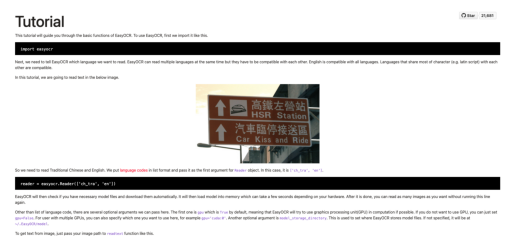

In [17]:
uploaded = files.upload()

img_path = next(iter(uploaded))  # This gets the name of the first (and possibly only) uploaded file
# Read and display the image
img = cv2.imread(img_path)
plt.imshow(img)
plt.axis('off')  # Optional: to not show axes for a cleaner image
plt.show()

In [24]:
reader = easyocr.Reader(['en'])
ocr_results = reader.readtext(img)
ocr_results

[([[1934, 0], [2006, 0], [2006, 24], [1934, 24]], 'CC', 0.3921730018894226),
 ([[1893, 21], [1927, 21], [1927, 37], [1893, 37]],
  'Star',
  0.6434430223963671),
 ([[1947, 17], [2005, 17], [2005, 37], [1947, 37]],
  '21,681',
  0.9988873821581431),
 ([[19, 19], [233, 19], [233, 85], [19, 85]], 'Tutorial', 0.8413091878835074),
 ([[19, 99], [111, 99], [111, 119], [19, 119]],
  'This tutorial',
  0.9989867865795974),
 ([[132, 96], [818, 96], [818, 122], [132, 122]],
  'Iguide you through the basic functions of EasyOCR: To use EasyOCR, first we import it like this_',
  0.5058761725499584),
 ([[41, 155], [103, 155], [103, 175], [41, 175]],
  'import',
  0.9992845864088759),
 ([[111, 159], [181, 159], [181, 177], [111, 177]],
  'easyocr',
  0.9991523190744221),
 ([[20, 209], [171, 209], [171, 229], [20, 229]],
  'Next, we need to tell',
  0.7684211985179726),
 ([[169, 205], [2022, 205], [2022, 231], [169, 231]],
  'EasyOCR which language we want to read. EasyOCR can read multiple languages a

In [21]:
simple_ocr_results = reader.readtext(img, detail = 0, paragraph=True)
simple_ocr_results

['Star 21,681',
 'Tutorial This tutorial will Iguide you through the basic functions of EasyOCR: To use EasyOCR, first we import it like this_',
 'import easyocr',
 'Next, we need to tell EasyOCR which language we want to read. EasyOCR can read multiple languages at the same time but they have to be compatible with each other: English is compatible with all languages. Languages that share most of character (e.g: latin script) with each other are compatible:',
 'In this tutorial, we are going to read text in the below image:',
 '30220 HSR Station {#EE512E Car Kiss and Ride',
 "So we need to read Traditional Chinese and English: We put language codes in list format and pass it as the first argument for Reader object: In this case, it is [ 'ch_tra",
 'en" ] _',
 'reader',
 "easyocr.Reader( [ 'ch_tra",
 "en' ] )",
 'EasyOCR will then check if you have necessary model files and download them automatically: It will then load model into memory which can take few seconds depending on your hard

-1

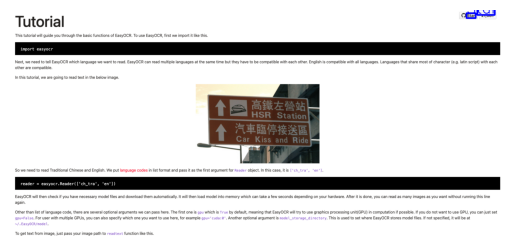

In [25]:
top_left = ocr_results[0][0][0]
bottom_right = ocr_results[0][0][2]

text = ocr_results[0][1]

img = cv2.rectangle(img, top_left, bottom_right, (0,0,255), 5)
img = cv2.putText(img, text, top_left, cv2.FONT_HERSHEY_SIMPLEX, 2, (0,0,255), 2, cv2.LINE_AA)

plt.imshow(img)
plt.axis('off')  # Optional: to not show axes for a cleaner image
cv2.waitKey(0)

-1

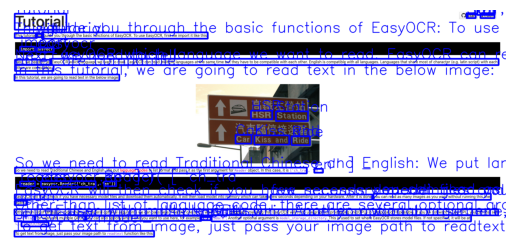

In [26]:
confidence_treshold = 0.4 # @param {type:"slider", min:0, max:1, step:0.1}

for detection in ocr_results:
    if detection[2] > confidence_treshold:
        top_left = [int(value) for value in detection[0][0]]
        bottom_right = [int(value) for value in detection[0][2]]
        text = detection[1]
        img = cv2.rectangle(img, top_left, bottom_right, (0,0,255), 5)
        img = cv2.putText(img, text, top_left, cv2.FONT_HERSHEY_SIMPLEX, 2, (0,0,255), 2, cv2.LINE_AA)

plt.imshow(img)
plt.axis('off')  # Optional: to not show axes for a cleaner image
cv2.waitKey(0)